## Imports

In [40]:
import re
import numpy as np
from collections import Counter
import nltk
# nltk.download('gutenberg')
#nltk.download('punkt')  #Download if file is not downloaded

from nltk.corpus import gutenberg
from nltk.tokenize import word_tokenize

## Load Dataset

In [41]:
gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [55]:
text = gutenberg.raw('carroll-alice.txt')

In [56]:
# with open("Text.txt", "r", encoding="utf-8") as f:
#     text = f.read()    #For our own text we can use this

print("Sample text:", text[:300])

Sample text: [Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversatio


## Preprocessing
-(Tokenization, Vocabulary, Encoding)

In [57]:
# def tokenize(text):
#     text = text.lower()
#     text = re.sub(r"[^a-z\s]", " ", text)  # keep only letters
#     tokens = text.split()
#     return tokens

def tokenize(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]   # keep only real words
    return tokens

tokens = tokenize(text)
print("First 20 tokens:", tokens[:20])


First 20 tokens: ['alice', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'chapter', 'down', 'the', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by']


In [58]:
def build_vocab(tokens, min_freq=1, max_vocab_size=None):
    counter = Counter(tokens)
    items = [(w, c) for w, c in counter.items() if c >= min_freq]
    items.sort(key=lambda x: -x[1])

    if max_vocab_size is not None:
        items = items[:max_vocab_size]

    word2id = {w: i for i, (w, _) in enumerate(items)}
    id2word = {i: w for w, i in word2id.items()}
    return word2id, id2word



def encode(tokens, word2id):
    return [word2id[w] for w in tokens if w in word2id]


In [59]:
tokens = tokenize(text)
word2id, id2word = build_vocab(tokens)
encoded = encode(tokens, word2id)

print("Vocab size:", len(word2id))
print("First 20 tokens:", tokens[:20])
print("First 20 encoded:", encoded[:20])

Vocab size: 2469
First 20 tokens: ['alice', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'chapter', 'down', 'the', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by']
First 20 encoded: [9, 438, 11, 785, 67, 1396, 1397, 287, 35, 0, 9, 10, 239, 2, 100, 24, 439, 7, 325, 67]


In [60]:
def subsample_tokens(tokens, word2id, t=1e-5):
    counter = Counter(tokens)
    total = len(tokens)
    freqs = {w: counter[w] / total for w in counter}

    result = []
    for w in tokens:
        if w not in word2id:
            continue
        prob = 1 - np.sqrt(t / freqs[w])
        if np.random.rand() > prob:
            result.append(w)
    return result

## Generate Skip-Gram pairs

In [61]:
def generate_skipgram_pairs(encoded_tokens, window_size=2):
    pairs = []
    for i, center in enumerate(encoded_tokens):
        start = max(0, i - window_size)
        end = min(len(encoded_tokens), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                context = encoded_tokens[j]
                pairs.append((center, context))
    return pairs


subsampled = subsample_tokens(tokens, word2id)
encoded_sub = encode(subsampled, word2id)

print("Length before subsampling:", len(encoded))
print("Length after subsampling:", len(encoded_sub))

pairs = generate_skipgram_pairs(encoded_sub, window_size=2)
print("Number of training pairs:", len(pairs))
print("First 10 pairs:", pairs[:10])

Length before subsampling: 25499
Length after subsampling: 2551
Number of training pairs: 10198
First 10 pairs: [(785, 239), (785, 1398), (239, 785), (239, 1398), (239, 34), (1398, 785), (1398, 239), (1398, 34), (1398, 790), (34, 239)]


In [82]:
def build_negative_distribution(tokens, word2id):

    counter = Counter(tokens)

    freqs = np.zeros(len(word2id))

    for w, c in counter.items():
        if w in word2id:
            freqs[word2id[w]] = c

    probs = freqs ** 0.75
    probs /= probs.sum()

    return probs

neg_distribution = build_negative_distribution(subsampled, word2id)
# sample_negative_words(neg_distribution, positive_context_id, K)

## Negative Sampling

In [83]:
def sample_negative_words(neg_distribution, positive_word, K=5):

    neg_samples = []

    while len(neg_samples) < K:
        neg = np.random.choice(len(neg_distribution), p=neg_distribution)

        if neg != positive_word:
            neg_samples.append(neg)

    return neg_samples
    
print("Example negative samples:", sample_negative_words(neg_distribution, positive_word=0, K=5))

Example negative samples: [20, 796, 417, 1054, 367]


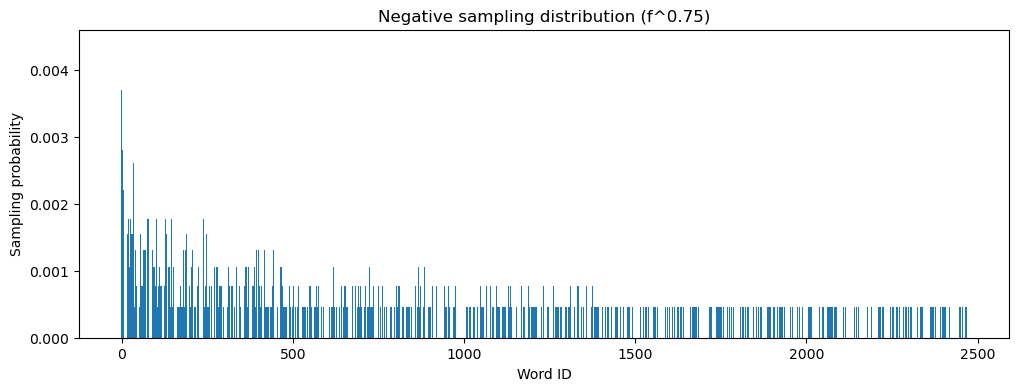

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.bar(range(len(neg_distribution)), neg_distribution)
plt.xlabel("Word ID")
plt.ylabel("Sampling probability")
plt.title("Negative sampling distribution (f^0.75)")
plt.show()

## Word2Vec Model (Numpy)

In [85]:
# def sigmoid(x):
#     return 1 / (1 + np.exp(-x))

def sigmoid(x):
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x))
    )

class Word2Vec:
    def __init__(self, vocab_size, embedding_dim=50, learning_rate=0.01):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.lr = learning_rate

        # Input embeddings (center words)
        self.W_in = np.random.randn(vocab_size, embedding_dim) * 0.01
        # Output embeddings (context words)
        self.W_out = np.random.randn(vocab_size, embedding_dim) * 0.01

    def forward(self, center_id, context_id, neg_ids):
        v_c = self.W_in[center_id]          # center word vector
        u_o = self.W_out[context_id]        # positive context vector
        u_neg = self.W_out[neg_ids]         # negative samples vectors

        # Positive score
        pos_score = np.dot(v_c, u_o)
        pos_prob = sigmoid(pos_score)

        # Negative scores
        neg_scores = np.dot(u_neg, v_c)
        neg_prob = sigmoid(-neg_scores)

        # Loss with numerical stability
        eps = 1e-10
        loss = -np.log(pos_prob + eps) - np.sum(np.log(neg_prob + eps))

        return pos_prob, neg_prob,neg_scores, loss, v_c, u_o, u_neg


    
    def backward(self, center_id, context_id, neg_ids, pos_prob, neg_prob,neg_scores, v_c, u_o, u_neg):
        
        # σ(u_k · v_c) = 1 - σ(-u_k · v_c)
        sigma_x_neg = 1.0 - neg_prob
        
        # Gradient for center word vector
        grad_v = (pos_prob - 1.0) * u_o + np.sum(sigma_x_neg[:, None] * u_neg, axis=0)

        # Gradient for positive context word
        grad_u_o = (pos_prob - 1.0) * v_c

        # Gradient for negative samples (vectorized update)
        grad_u_neg = sigma_x_neg[:, None] * v_c



        # gradient clipping !!!!
        grad_v = np.clip(grad_v, -1, 1.0)
        grad_u_o = np.clip(grad_u_o, -1.0, 1.0)
        grad_u_neg = np.clip(grad_u_neg, -1.0, 1.0)

        # Update embeddings
        self.W_in[center_id] -= self.lr * grad_v
        self.W_out[context_id] -= self.lr * grad_u_o
        self.W_out[neg_ids] -= self.lr * grad_u_neg


    def train_step(self, center_id, context_id, neg_ids):
        pos_prob, neg_prob,neg_scores, loss, v_c, u_o, u_neg = self.forward(center_id, context_id, neg_ids)
        self.backward(center_id, context_id, neg_ids, pos_prob, neg_prob,neg_scores, v_c, u_o, u_neg)
        return loss

## Training loop

In [91]:
# Initialize model
embedding_dim = 50
learning_rate = 0.025
epochs = 20
K = 5  # number of negative samples

model = Word2Vec(vocab_size=len(word2id), embedding_dim=embedding_dim, learning_rate=learning_rate)

loss_history = []

for epoch in range(epochs):
    total_loss = 0

    # Shuffle training pairs
    np.random.shuffle(pairs)

    for center, context in pairs:
        neg_ids = sample_negative_words(neg_distribution, context, K=K)
        loss = model.train_step(center, context, neg_ids)
        total_loss += loss

    avg_loss = total_loss / len(pairs)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_loss:.4f}")

Epoch 1/20 - Average Loss: 4.1589
Epoch 2/20 - Average Loss: 4.1588
Epoch 3/20 - Average Loss: 4.1587
Epoch 4/20 - Average Loss: 4.1585
Epoch 5/20 - Average Loss: 4.1582
Epoch 6/20 - Average Loss: 4.1574
Epoch 7/20 - Average Loss: 4.1554
Epoch 8/20 - Average Loss: 4.1500
Epoch 9/20 - Average Loss: 4.1362
Epoch 10/20 - Average Loss: 4.1023
Epoch 11/20 - Average Loss: 4.0298
Epoch 12/20 - Average Loss: 3.8996
Epoch 13/20 - Average Loss: 3.7202
Epoch 14/20 - Average Loss: 3.5193
Epoch 15/20 - Average Loss: 3.3254
Epoch 16/20 - Average Loss: 3.1596
Epoch 17/20 - Average Loss: 3.0282
Epoch 18/20 - Average Loss: 2.9308
Epoch 19/20 - Average Loss: 2.8591
Epoch 20/20 - Average Loss: 2.8072


## Similarity Queries

In [92]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def get_vector(word):
    return model.W_in[word2id[word]]

def most_similar(word, top_n=5):
    if word not in word2id:
        raise ValueError(f"'{word}' is not in the vocabulary.")

    target_vec = get_vector(word)
    norms = np.linalg.norm(model.W_in, axis=1)
    sims = (model.W_in @ target_vec) / (norms * np.linalg.norm(target_vec))
    
    # exclude the word itself
    best_ids = np.argsort(-sims)
    best_ids = [i for i in best_ids if i != word2id[word]][:top_n]
    return [id2word[i] for i in best_ids]

# Example usage
print("Most similar to 'understand':", most_similar("understand"))

Most similar to 'understand': ['sends', 'least', 'adding', 'severely', 'knocking']


In [93]:
list(word2id.keys())[:21]

['the',
 'and',
 'to',
 'a',
 'she',
 'i',
 'it',
 'of',
 'said',
 'alice',
 'was',
 'in',
 'you',
 'that',
 'as',
 'her',
 'at',
 'on',
 'had',
 'with',
 'all']

In [80]:
most_similar("her")

['and', 'i', 'alice', 'had', 'a']